In [1]:
# 📌 Project Context (Linear Regression – House Price Prediction)
# This project aims to predict house prices using Multiple Linear Regression.
# The model learns a linear relationship between input features (area, bedrooms, location factors, etc.) and the target variable (price).

# Linear Regression assumes:
            # y= beta0 + beta1x1 + beta2x2 +...+ betanxn
# Where:
# y = predicted price
# β = coefficients
# x = input features

# The model was trained on approximately 500 data samples.
# Model performance:
# Train R² ≈ 0.70
# Test R² ≈ 0.67
# Residual analysis shows errors are centered around zero with slight positive skew.

# ⚠ Limitations / Disadvantages:
# 1. Assumes Linear Relationship
# Real estate prices may have nonlinear patterns.
# Linear regression cannot capture complex interactions.

# 2. Limited Dataset (500 rows)
# Small dataset reduces generalization capability.
# Tree-based models (like Random Forest) may not perform well with limited data.

In [2]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("Housing.csv")

print(df.head())
print(df.isnull().sum())
print(df.describe())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
price               0
area                0
bedrooms            0
bathrooms           0
stories    

In [3]:
# Convert yes/no to 1/0
order = {
    'yes': 1,
    'no': 0
}

df['mainroad'] = df['mainroad'].map(order)
df['guestroom'] = df['guestroom'].map(order)
df['basement'] = df['basement'].map(order)
df['hotwaterheating'] = df['hotwaterheating'].map(order)
df['airconditioning'] = df['airconditioning'].map(order)
df['prefarea'] = df['prefarea'].map(order)

In [4]:
# One-hot encoding
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

In [5]:
# Correlation
corr = df.corr()
price_corr = corr['price'].sort_values(ascending=False)
print(price_corr)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


In [6]:
# Features & Target
X = df.drop('price', axis=1)
y = df['price']

In [7]:
# Log transform target
y = np.log1p(y)

In [8]:
# Train test split
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
# Predictions
y_pred = lr.predict(X_test_scaled)

In [12]:
# Log scale metrics
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Log Scale MSE: {mse:.3f}")
print(f"Log Scale RMSE: {rmse:.3f}")
print("Train R2:", lr.score(X_train_scaled, y_train)) 
print("Test R2 :", lr.score(X_test_scaled, y_test))

Log Scale MSE: 0.063
Log Scale RMSE: 0.252
Train R2: 0.7039055526365164
Test R2 : 0.6722047416501382


In [13]:
# Convert back to original price
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

# Actual RMSE in ₹
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
print("Actual RMSE in Price:", rmse_actual)

Actual RMSE in Price: 1314648.195413727


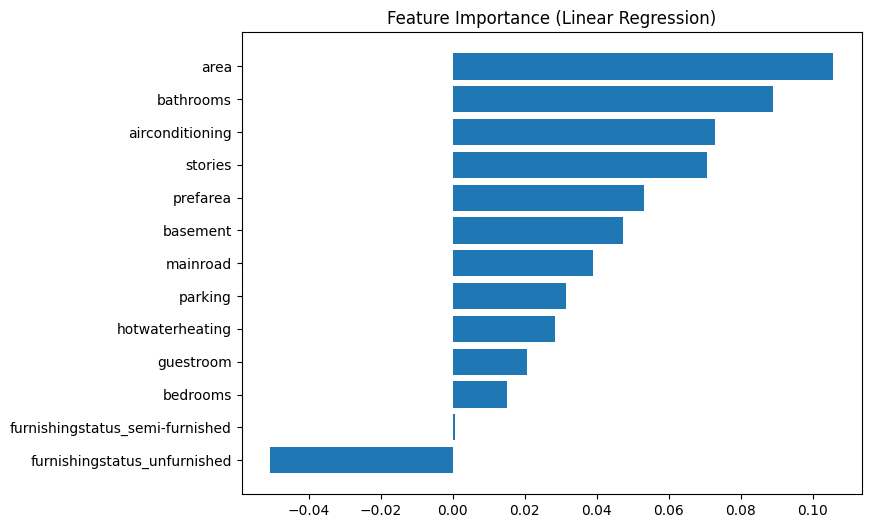

In [14]:
# Feature Importance (Linear Regression Coefficients)
import matplotlib.pyplot as plt

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'])
plt.title("Feature Importance (Linear Regression)")
plt.show()

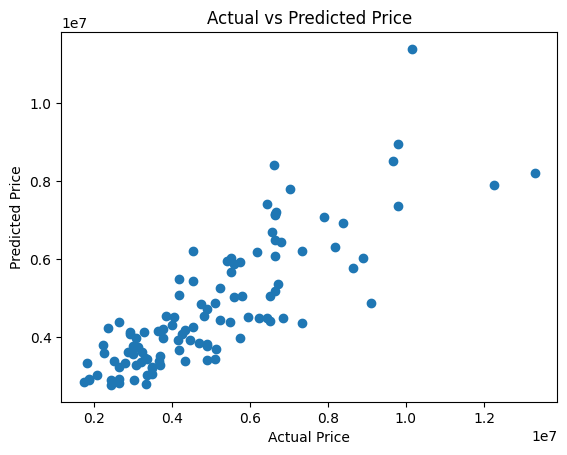

In [15]:
# Visualization (Original Price)

plt.figure()
plt.scatter(y_test_actual, y_pred_actual)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

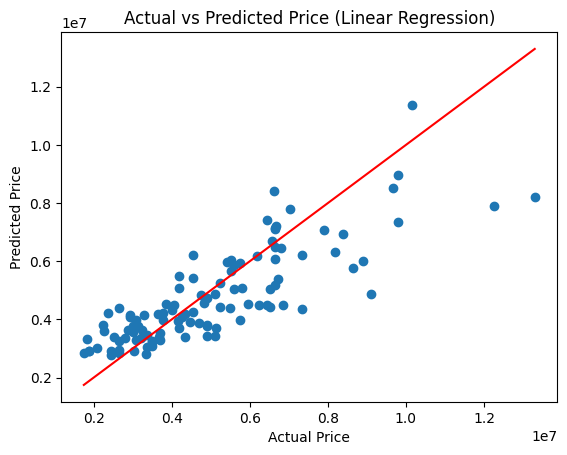

In [16]:
# Linear Regression Visualization (with Ideal Line)
plt.figure()
plt.scatter(y_test_actual, y_pred_actual)

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    color='red'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Linear Regression)")
plt.show()

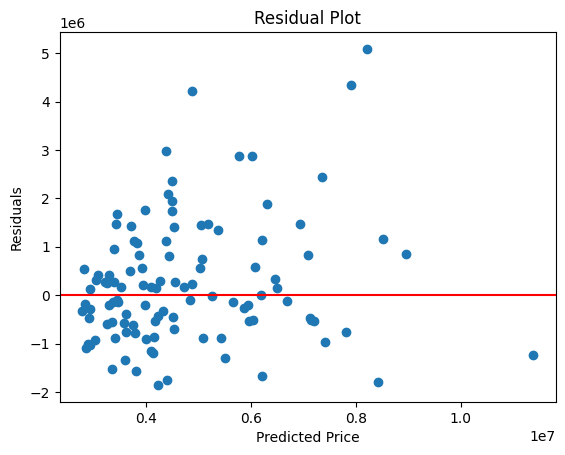

In [17]:
residuals = y_test_actual - y_pred_actual

plt.figure()
plt.scatter(y_pred_actual, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

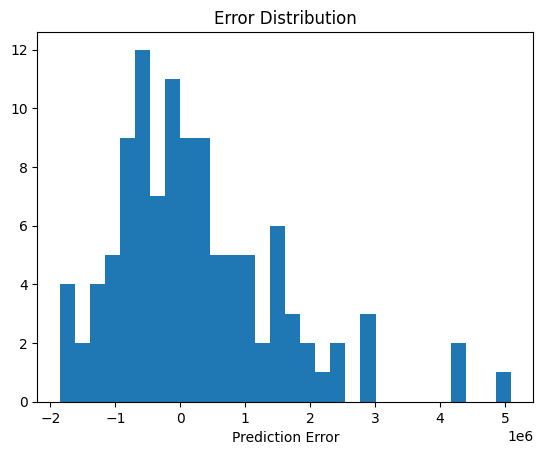

In [18]:
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Prediction Error")
plt.title("Error Distribution")
plt.show()